# MAB Price Optimization

### Abstract

Objective  - Price Optimization without assuming demand shape


Price optimization is applied (tested) on three exemplary demand functions
* linear demand
* constant elasticity demand
* logit demand

Price optimization functions
* linear
* log_lg
* log_quadratic
* log_linear

General Findings


### Organization of this notebook
* Notebook setup
* Demand parameters
* Demand curves
* Demand samples
* Elasticity vs. Inverse Unit Margin
* Demand Fit Theory
* MAB Loop: Optimum Demand, Price, Profit
* Evaluate MAB Results

# Price and Profit Optimization Algorithm and Diagnostics

Log Quadratic
$$
\log \, d = \beta_0 + \beta_1 \, \log p + \beta_2 (\log p)^2
$$

if $\beta_2 \approx 0$, elasiticiay is approximately constant and log quadratic collapses naturally to log-log (constant elasticity).

However if $\beta_2$ is meaningfully nonzero, there is evidence that elasticity varies with price. 

Model Selection
```text
                  FIT ALL THREE MODELS
             linear | log-log | log-quadratic
              |           |         |
            tilt        tilt      tilt
            adjust       adjust    adjust
              |           |         |
              +-----------+---------+
                          |
                          v
                Select best model by fit
                       (AIC)
                          |
             +------------+------------+
             |                         |
          LINEAR                    LOG MODEL
             |                         |
             v                         v
        keep LINEAR        Diverged from LINEAR?
                           |p*_log - p*_linear|
                           / price_range > threshold
                               /          \
                             YES           NO
                              |             |
                              v             v
                           LINEAR      Which log model?
                                          |
                              +-----------+-----------+
                              |                       |
                           LOG-LOG                LOG-QUADRATIC
                              |                       |
                              v                       v
                         keep LOG-LOG       Is quadratic term
                                            justified by AIC?
                                                /      \
                                              YES       NO
                                               |         |
                                               v         v
                                         LOG-QUADRATIC  LOG-LOG
                
```           

Selection Logic:

1. Fit all three models, each with its tilt adjustment.
2. Select the best-fitting model using AIC.
3. If AIC selected linear, done.
4. If AIC selected either log model, first compare that selected model's p_opt_hat with linear's p_opt_hat

5. If the normalized difference exceeds p_opt_linear_delta_frac_max = 0.15, fall back immediately to linear.
6. Only if the selected log model passes that divergence test do we care which log model it is.
7. If it's log-log, keep it.
8. If it's log-quadratic, require the improvement over log-log to exceed logq_aic_improvement_min = 2.0; otherwise simplify to log-log.

tilt

Our earlier investigation showed that, with relatively few noisy demand observations, a fitted curve could have a reasonable overall fit but be slightly tilted relative to the underlying demand relationship. That small slope error could translate into a surprisingly large error in the profit-maximizing price.

Rather than imposing a hard constraint on the fitted coefficients, we introduced a soft tilt penalty during estimation 

$$
tilt_error = a^T (target - X0)
$$

and penalize

$$
\lambda_{tilt}(tilt_error)^2
$$

Next Steps

1. Clean up select_demand_model. Remove obsolete selection logic while retaining useful diagnostics. We now have a much clearer conceptual architecture: fit → select on fit → AIC complexity check for log-quadratic → divergence guard against linear.

2. Store predictions for every candidate model, not merely the selected model. In particular, I would make the diagnostics for each model self-contained enough that later we can inspect something conceptually like:

3. Re-examine the actual curves before inventing another correction. This is now the most valuable step. For cases like at the high end - linear fall back p_opt_hat ~ 3.10, log models fail at boundry p_opt_hat = 4. ... ,  at the low end (p_opt_hat = 2.51), and some of the very accurate runs, we can plot on the same data:
observed demand
* true demand (simulation only)
* all three fitted demand curves
* all three profit curves / estimated optima
* possibly elasticity curves

That should tell us whether the remaining error comes primarily from tilt, curvature, noisy local data around the optimum, or the profit maximization amplifying a relatively small demand-fit error.

the linear fallback is doing what we intended: acting as a conservative guardrail rather than trying to be the preferred functional form.

There is still a modest upward bias, about 2.834−2.70=0.134, and a few interesting cases remain. 

# Notebook Setup

In [1]:
!python --version

Python 3.12.7


In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path("..") / "py_modules"))

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import beautifulplots as bp


from demand_elasticity_profit import (
    demand_constant_elasticity, 
    demand_linear, elasticity_linear,
    demand_logit, elasticity_logit,
    get_vhat_invumar_df,
)

from utils_probability import demand_sample

# Demand Parameters

Business Parameters

These parameters are contexttual to the business problem and are necessary to model demand behavior.
* CV - coefficient of variation. Represents the demand variation relative to the mean, $CV = \sigma/\mu$
* c - cost per unit.
* F - fixed cost.

Below (code cell), we use the term `sigma_log` because the standard deviation corresponds to the log domain corresponding to log D demand variations - additive in the log domain (log scale) and multiplicative in the linear domain  (.e., demand with multiplicative "noisy" variation). This is the typical representation for market demand situations. This $sigma_log$ is often simply termed $\sigma$ in the literature, however both represent stadnard-deviation in the log domain.

In [3]:
# Demand General Parameters
CV =0.2 
v = 1.8
c = 1.2
F = 6
sigma_log = np.sqrt(np.log1p(CV**2)) # sqrt(1 + CV^2)


print(f'CV = {CV}, Coefficient of Variation')
print(f'sigma_log = {sigma_log}')
print(f'v = {1.8}, elasticity')
print(f'c = {c}, variable costs')
print(f'F = {F}, Fixed costs')


CV = 0.2, Coefficient of Variation
sigma_log = 0.19804220043536505
v = 1.8, elasticity
c = 1.2, variable costs
F = 6, Fixed costs


Additonal price parameters
*  p0, is the currently set market price, though it is not optimal.
*  price_min - minimum price guard rail
*  price_max - maximum price guard rail

In [4]:
p0 = 3.6
price_min = 2
price_max = 4.0
print(f'p0 = {p0}, initial price')
print(f'price_min = {price_min}, minimum price')
print(f'price_max = {price_max}, maximum price')

p0 = 3.6, initial price
price_min = 2, minimum price
price_max = 4.0, maximum price


For exemplary purposes, we set the following objectives across the demand functions
1. Profit optimizing price, p_opt, is the same across all the demand functions 
2. Demand, d(p_opt) is the same for all three demand examples.
3. Elasticity at p_opt, is the same for all demand examples.

Demand parameters for the three demand functions - constant elasticity, linear demand, logit demand

We begin with constant elasticity, because it provides conceptual understanding of elasticity. Then, we will set the parameters for the other demand functions to aligned with the profit optimizing price, p_opt, and corresponding elasticity.

In [5]:
# Demand Parameters

#### Constant Elasticity Demand ###
v = 1.8
p_opt = (v / (v - 1)) * c
A_ce = 4000
D_opt = A_ce * p_opt **(-v)
Profit_opt = p_opt * D_opt - c * D_opt - F  

#### linear demand ####
#  - match the slope of the constant elasticity demand at p_opt
#  d_linear = A ( 1 - bp )
#  p_zero = A / b
#  d_linear(p_opt) = d_ce(p_opt)
#  A (1 - b * p_opt) = A * p_opt **(-v)
#  A is known, solve for b
b_linear = v / (( 1 + v) * p_opt)
A_linear = D_opt / (1 - b_linear * p_opt) # A = d(p_opt) / (1 - b * p_opt)

###### Logit #######
# need to solve for a and b
# constraints:
#  1) v_logit(p_opt) =  v = 1.8
#  2) pmid = p_opt
#  b_logit = 2 * v / p_opt ... 
#  a_logit = b_logit * p_opt ... sets the midpoint for logit demand
b_logit =  2 * v / p_opt
a_logit =  b_logit * p_opt
A_logit = 2 * D_opt # Logit demand is A/2 at p_opt

# Constant Elasticity Demand
print('Connstant Elasticity Demand')
print(f'  p_opt = {p_opt}')
print(f'  D_opt = {D_opt}')
print(f'  v = {v}')
print(f'  A_ce = {A_ce}')
print(f'  Profit_opt = {Profit_opt}')

# Linear Demand
print()
print('Linear Demand')
print(f'  A_linear = {A_linear}')
print(f'  b_linear = {b_linear}')

# Logit De`mand
print()
print("Logit Demand")
print(f'  A_logit = {A_logit}')
print(f'  b_logit = {b_logit}')
print(f'  a_logit = {a_logit}')


Connstant Elasticity Demand
  p_opt = 2.6999999999999997
  D_opt = 669.2759448378242
  v = 1.8
  A_ce = 4000
  Profit_opt = 997.9139172567361

Linear Demand
  A_linear = 1873.972645545908
  b_linear = 0.23809523809523814

Logit Demand
  A_logit = 1338.5518896756485
  b_logit = 1.3333333333333335
  a_logit = 3.6


# Revenue Profit Costs

In [6]:
Profit_opt = (p_opt -c) * D_opt -  F

R_opt = p_opt * D_opt

MC = c # marginal cost

TC_p_opt = c * D_opt + F
TCPU_p_opt = TC_p_opt / D_opt

RPU_D_opt = R_opt / D_opt
Profit_opt

print(f'Profit_opt = {Profit_opt}')

Profit_opt = 997.9139172567362


# MAB Loop: Optimum Demand, Price, Profit

In [7]:
from demand_price_estimation import mab_price_optimization_loop, get_demand

Candidate model types

* linear:   d = beta_0 + beta_1 * p    + gamma' x
* log_level:  log(d) = beta_0  + beta_1 * p + gamma' x
* log_log: log(d) = beta_0 + beta_1 * log(p) + gamma' x
* log_quadratic:  log(d) = beta_0   + beta_1 * log(p)  + beta_2 * log(p)^2 + gamma' x

Statistical Accuracy Features

* Fit model to the observed (noisy) demand and estimate elasticity vhat from the fitted curve.

* Model selection criteria
  * Four candidate model types - linear, log_level, log_log, log_quadratic with selection criteria: residual error to the fitted curve + boundary penalty  (p_opt close to price boundary)
  * Leave one out CV, 10 or more samples
  * Positive demand: $\hat d (p) > 0$ especially at price boundaries (price_min, price_max)
  * Elasticity negative in p_opt region: $d \hat d (p) < 0$ in a neighbord around p_opt or preferably accross the grid
  * Curvature is limited, since it will affect vhat accuracy
  * flag or penalize optima substantially outside the observed price range.

MAB Expriments
* Nexperiments
* Evaluate and Compare
  * p_opt_hat statistics
  * selected modedl types

In [21]:
# MAB Loop Paramter Setup

# Demand model used to generate simulated observations
demand_type = "constant_elasticity"
#demand_type = "linear"
#demand_type = "logit"

demand_params = {}
if demand_type == "constant_elasticity":
    demand_params = {"A": A_ce, "v": v, }

elif demand_type == "linear":
    demand_params = { "A": A_linear, "b": b_linear  }

elif demand_type == "logit":
    demand_params = {  "A": A_logit,"a": a_logit, "b": b_logit,}
    
# fit model
candidate_model_types = [ "linear", "log_level", "log_log", "log_quadratic"] # model types    
candidate_model_types = [ "linear", "log_quadratic", "piecewise_linear"] # model types   
candidate_model_types = [ "linear", "log_quadratic"] # model types 
candidate_model_types = [ "linear","log_log" ,"log_quadratic"] # model types 
#candidate_model_types = [  "piecewise_linear"] # model types 
#candidate_model_types = [ "linear", "piecewise_linear"] # model types 
#candidate_model_types = [  "piecewise_log_log"] # model types 
#candidate_model_types = [ "linear", "log_quadratic",  "piecewise_log"] # model types    
#candidate_model_types = [ "linear", "log_log", "log_quadratic"] # model types    
#candidate_model_types = [ "linear", "log_level", "log_log" ] # model types 
#candidate_model_types = [ "linear" ] # model types 

# Each model mathhes a demand type for example linear the linear demand, log-log constant elasticity, and log-quadratic logit. Log-level is a simpler model. Since AIC/BIC already penalize complexity, leaving log_level in has little downside. It helps provide an alternative if other models are at the boundary. Remove it only if repeated simulations show that excluding it materially improves out-of-sample price/profit accuracy across all three demand types.

sigma_lg = sigma_log
#sigma_lg = 0.05
#sigma_lg = 0


N_experiments = 30
N_loop = 30
N_price_repeat=2
N_initial_prices = 12
boundary_buffer = .04
huber = False
ridge_cv = False
N_regions = 10 # piecwise models, number of regions to fit
N_overlap = 7 # piecwise models, number of observations shared around adjacent regions
tilt_penalty_linear = 1.0 # linear tilt penalty, 1.0 is default, 0.0 is no penalty > 1 (e.g., 4)
tilt_penalty_log_log = 5.0 # log-log tilt penalty, 1.0 is default, 0.0 is no penalty > 1 (e.g., 4)
tilt_penalty_log_quadratic = 5.0 # log-quadratic tilt penalty, 1.0 is default, 0.0 is no penalty > 1 (e.g., 4)
logq_aic_improvement_min=2.0
p_opt_linear_delta_frac_max=0.15

print(f'N_experiments = {N_experiments}')
print(f'Nloop = {N_loop}')
print(f'Nprice_repeat = {N_price_repeat}')
print(f'N_initial_prices = {N_initial_prices}')
print(f'N_overlap = {N_overlap}')
print(f'N_regions = {N_regions}')
print(f'boundary_buffer = {boundary_buffer}')
print(f"demand_type = {demand_type}")
print(f"demand_params = {demand_params}")
print(f'ridge_cv = {ridge_cv}')
print(f'huber = {huber}')
print(f"sigma_lg = {sigma_lg}")
print(f"candidate_model_types = {candidate_model_types}")
print(f"tilt_penalty_linear = {tilt_penalty_linear}")
print(f"tilt_penalty_log_log = {tilt_penalty_log_log}")
print(f"tilt_penalty_log_quadratic = {tilt_penalty_log_quadratic}")
print(f"logq_aic_improvement_min = {logq_aic_improvement_min}")
print(f"p_opt_linear_delta_frac_max = {p_opt_linear_delta_frac_max}")

N_experiments = 30
Nloop = 30
Nprice_repeat = 2
N_initial_prices = 12
N_overlap = 7
N_regions = 10
boundary_buffer = 0.04
demand_type = constant_elasticity
demand_params = {'A': 4000, 'v': 1.8}
ridge_cv = False
huber = False
sigma_lg = 0.19804220043536505
candidate_model_types = ['linear', 'log_log', 'log_quadratic']
tilt_penalty_linear = 1.0
tilt_penalty_log_log = 5.0
tilt_penalty_log_quadratic = 5.0
logq_aic_improvement_min = 2.0
p_opt_linear_delta_frac_max = 0.15


In [22]:



print(logq_aic_improvement_min)
print(type(logq_aic_improvement_min))

2.0
<class 'float'>


In [23]:
# ==========================================================
# MAB Experiments
# ==========================================================

# ----------- print experiment parameters -----------

print(f"candidate_model_types = {candidate_model_types}")
print(f"demand_type = {demand_type}")
print(f"N_overlap = {N_overlap}")
print(f"N_regions = {N_regions}")
print(f'ridge_cv = {ridge_cv}')
print(f'huber = {huber}')
print(f"tilt_penalty_linear = {tilt_penalty_linear}")
print(f"tilt_penalty_log_log = {tilt_penalty_log_log}")
print(f"tilt_penalty_log_quadratic = {tilt_penalty_log_quadratic}")


# ------------ histories -----------------------------
k_history = []
demand_type_history = []
selected_model_history = []
p_opt_hat_history = []
p_opt_hat_error_history = []
d_opt_hat_history = []
sigma_log_history = []

results_dict_list = []

vhat_delta_history = []

linear_vhat_delta_history = []


linear_aic_history = []
log_quadratic_aic_history = []

linear_p_opt_hat_history = []
log_quadratic_p_opt_hat_history = []

vhat_region_mean_history = []
vhat_region_median_history = []

p_opt_region_mean_history = []
p_opt_region_median_history = []

tilt_error_linear_history = []
tilt_error_log_quadratic_history = []

log_log_aic_history = []
log_log_p_opt_hat_history = []
log_log_tilt_error_history = []

log_quad_beta1_history = []
log_quad_beta2_history = []



logq_vs_loglog_aic_improvement_history = []

markup_pct_delta_history = []

p_opt_linear_delta_frac_history = []

print(f"demand_type = {demand_type}")

for k in range(N_experiments):

    print("k = ", k, end=", ")

    results_dict = mab_price_optimization_loop(
        price_min,
        price_max,
        c,
        F,
        p_opt,
        demand_type,
        demand_params,
        sigma_lg,
        N_loop=N_loop,
        N_price_repeat=N_price_repeat,
        candidate_model_types=candidate_model_types,
        ridge_cv=ridge_cv,
        huber=huber,
        boundary_buffer=boundary_buffer,
        N_initial_prices=N_initial_prices,
        N_regions=N_regions,
        N_overlap=N_overlap,
        tilt_penalty_linear=tilt_penalty_linear,  
        tilt_penalty_log_quadratic=tilt_penalty_log_quadratic,
        tilt_penalty_log_log=tilt_penalty_log_log,
        logq_aic_improvement_min=logq_aic_improvement_min,
        p_opt_linear_delta_frac_max=p_opt_linear_delta_frac_max,
        verbose=1,
    )
    
    model_diagnostics_k = (
    results_dict["model_diagnostics_history"][-1]
    )

    results_dict_list.append(results_dict)

    # ---------- Final result from experiment ----------#

    selected_model_k = results_dict["selected_model"][-1]
    p_opt_hat_k = results_dict["p_opt_hat_history"][-1]
    d_opt_hat_k = results_dict["d_opt_hat_history"][-1]

    # ---------- Store experiment results ----------#

    k_history.append(k)
    demand_type_history.append(demand_type)
    selected_model_history.append(selected_model_k)
    p_opt_hat_history.append(p_opt_hat_k)
    d_opt_hat_history.append(d_opt_hat_k)
    sigma_log_history.append(sigma_lg)


    p_opt_hat_error_history.append(
        abs(p_opt_hat_k - p_opt)
    )



    # diagnostics for linear and log_quadratic models
    linear_aic_history.append(
        model_diagnostics_k["linear"]["aic"]
    )
    
    log_log_aic_history.append(
        model_diagnostics_k["log_log"]["aic"]
    )
    log_quadratic_aic_history.append(
        model_diagnostics_k["log_quadratic"]["aic"]
    )

    linear_p_opt_hat_history.append(
    model_diagnostics_k["linear"]["p_opt_hat"]
    )
    

    log_quadratic_p_opt_hat_history.append(
        model_diagnostics_k["log_quadratic"]["p_opt_hat"]
    )
    
    # log_log vhat history

    
    
    # region diagnostics for piecewise models

    p_opt_region_mean_history.append(
        model_diagnostics_k["linear"]["p_opt_region_mean"]
    )

    p_opt_region_median_history.append(
        model_diagnostics_k["linear"]["p_opt_region_median"]
    )
    

    
    # tilt error diagnostics for linear and log_quadratic models
    tilt_error_linear_history.append(
    model_diagnostics_k["linear"]["tilt_error"]
    )

    tilt_error_log_quadratic_history.append(
        model_diagnostics_k["log_quadratic"]["tilt_error"]
    )
    

    log_log_p_opt_hat_history.append(
        model_diagnostics_k["log_log"]["p_opt_hat"]
    )

    log_log_tilt_error_history.append(
        model_diagnostics_k["log_log"]["tilt_error"]
    )
    
    log_quad_beta1_history.append(
        model_diagnostics_k[
            "log_quadratic"
        ]["beta1"]
    )

    log_quad_beta2_history.append(
        model_diagnostics_k[
            "log_quadratic"
        ]["beta2"]
    )


        



    
    logq_vs_loglog_aic_improvement_history.append(
        model_diagnostics_k["log_log"]["aic"]
        - model_diagnostics_k["log_quadratic"]["aic"]
    )
    


    p_opt_linear_delta_frac_history.append(
        model_diagnostics_k["linear"]["p_opt_linear_delta_frac"]
    )

# ---------- Experiment dataframe ----------#

df_experiments = pd.DataFrame({
    "k": k_history,
    "demand_type": demand_type_history,
    "sigma_log": sigma_log_history,
    "selected_model": selected_model_history,
    "p_opt_hat": p_opt_hat_history,
    "p_opt_error": p_opt_hat_error_history,
    "d_opt_hat": d_opt_hat_history,
    
    # linear and log_quadratic model diagnostics
    "linear_aic": linear_aic_history,
    "log_quadratic_aic": log_quadratic_aic_history,
    "linear_p_opt_hat": linear_p_opt_hat_history,
    "log_quadratic_p_opt_hat": log_quadratic_p_opt_hat_history,
    
    "log_log_aic": log_log_aic_history,
    "log_log_p_opt_hat": log_log_p_opt_hat_history,
    
    
    # log-quadratic structural diagnostics
    
    "log_quad_beta1": log_quad_beta1_history,
    "log_quad_beta2": log_quad_beta2_history,

    "p_opt_region_mean": p_opt_region_mean_history,
    "p_opt_region_median": p_opt_region_median_history,
    
    # tlt error
    "tilt_error_linear": tilt_error_linear_history,
    "log_log_tilt_error": log_log_tilt_error_history,
    "tilt_error_log_quadratic": tilt_error_log_quadratic_history,
    
        
     "logq_vs_loglog_aic_improvement":
        logq_vs_loglog_aic_improvement_history,
        
        
    "p_opt_linear_frac": p_opt_linear_delta_frac_history

})


cols =[  "k",  "selected_model", "p_opt_hat","p_opt_error",  "linear_p_opt_hat",
            "log_log_p_opt_hat",  "log_quadratic_p_opt_hat",  "log_quad_beta1",
            "log_quad_beta2",   "logq_vs_loglog_aic_improvement"]

display(  df_experiments[cols].sort_values(   "p_opt_error", ascending=False))

print(f'N_experiments = {N_experiments}')
print(f'Nloop = {N_loop}')
print(f'Nprice_repeat = {N_price_repeat}')
print(f'N_initial_prices = {N_initial_prices}')
print(f'N_overlap = {N_overlap}')
print(f'N_regions = {N_regions}')
print(f'boundary_buffer = {boundary_buffer}')
print(f"demand_type = {demand_type}")
print(f"demand_params = {demand_params}")
print(f'ridge_cv = {ridge_cv}')
print(f'huber = {huber}')
print(f"sigma_lg = {sigma_lg}")
print(f"candidate_model_types = {candidate_model_types}")
print(f"tilt_penalty_linear = {tilt_penalty_linear}")
print(f"tilt_penalty_log_log = {tilt_penalty_log_log}")
print(f"tilt_penalty_log_quadratic = {tilt_penalty_log_quadratic}")
print(f"logq_aic_improvement_min = {logq_aic_improvement_min}")
print(f"p_opt_linear_delta_frac_max = {p_opt_linear_delta_frac_max}")

display(
    df_experiments["p_opt_hat"].describe()
)

candidate_model_types = ['linear', 'log_log', 'log_quadratic']
demand_type = constant_elasticity
N_overlap = 7
N_regions = 10
ridge_cv = False
huber = False
tilt_penalty_linear = 1.0
tilt_penalty_log_log = 5.0
tilt_penalty_log_quadratic = 5.0
demand_type = constant_elasticity
k =  0, i = 0, i = 1, i = 2, i = 3, i = 4, i = 5, i = 6, i = 7, i = 8, i = 9, i = 10, i = 11, i = 12, i = 13, i = 14, i = 15, i = 16, i = 17, i = 18, i = 19, i = 20, i = 21, i = 22, i = 23, i = 24, i = 25, i = 26, i = 27, i = 28, i = 29, selected_model = linear , p_opt_hat = 2.83 , p_opt_vhat_i = 2.84 , p_opt_hat_error = 0.13 , vhat_opt_i = 1.73 , inv_umar_i = 1.74 , d_opt_hat = 677.4 , d_sigma0_i = 611.1 , profit_opt_hat = 1100.69
k =  1, i = 0, i = 1, i = 2, i = 3, i = 4, i = 5, i = 6, i = 7, i = 8, i = 9, i = 10, i = 11, i = 12, i = 13, i = 14, i = 15, i = 16, i = 17, i = 18, i = 19, i = 20, i = 21, i = 22, i = 23, i = 24, i = 25, i = 26, i = 27, i = 28, i = 29, selected_model = log_log , p_opt_hat = 2.73 , p_o

,k,selected_model,p_opt_hat,p_opt_error,linear_p_opt_hat,log_log_p_opt_hat,log_quadratic_p_opt_hat,log_quad_beta1,log_quad_beta2,logq_vs_loglog_aic_improvement
13,13,linear,3.12,4.200000e-01,3.118236,4.000000,4.000000,-3.432160,0.989273,-0.618724
10,10,linear,3.10,4.000000e-01,3.102204,3.318637,3.042084,1.076418,-1.226208,0.230133
26,26,log_log,2.99,2.900000e-01,2.985972,2.985972,4.000000,-2.858178,0.599872,-1.575957
7,7,log_log,2.97,2.700000e-01,2.905812,2.973948,2.000000,-4.011986,1.031526,-1.303846
28,28,linear,2.91,2.100000e-01,2.905812,2.533066,2.737475,-1.004558,-0.384828,-1.972493
8,8,linear,2.90,2.000000e-01,2.897796,2.488978,2.745491,1.063266,-1.406704,1.071552
24,24,log_quadratic,2.90,2.000000e-01,2.989980,3.022044,2.901804,1.828611,-1.659297,4.011264
3,3,log_log,2.89,1.900000e-01,2.957916,2.885772,3.030060,-2.209235,0.249822,-1.961829
23,23,log_log,2.51,1.900000e-01,2.805611,2.513026,2.000000,-4.293157,1.104287,0.130917
22,22,linear,2.87,1.700000e-01,2.865731,2.521042,2.673347,-0.497224,-0.670255,-0.901514


N_experiments = 30
Nloop = 30
Nprice_repeat = 2
N_initial_prices = 12
N_overlap = 7
N_regions = 10
boundary_buffer = 0.04
demand_type = constant_elasticity
demand_params = {'A': 4000, 'v': 1.8}
ridge_cv = False
huber = False
sigma_lg = 0.19804220043536505
candidate_model_types = ['linear', 'log_log', 'log_quadratic']
tilt_penalty_linear = 1.0
tilt_penalty_log_log = 5.0
tilt_penalty_log_quadratic = 5.0
logq_aic_improvement_min = 2.0
p_opt_linear_delta_frac_max = 0.15


count    30.000000
mean      2.834333
std       0.123782
min       2.510000
25%       2.770000
50%       2.850000
75%       2.885000
max       3.120000
Name: p_opt_hat, dtype: float64

In [16]:
# Boundary
display(df_experiments[df_experiments["p_opt_hat"]>3.4])

,k,demand_type,sigma_log,selected_model,p_opt_hat,p_opt_error,d_opt_hat,vhat_rmse,piecewise_vhat_at_popt,vhat_delta,...,p_opt_region_mean,p_opt_region_median,tilt_error_linear,log_log_tilt_error,tilt_error_log_quadratic,log_quad_vhat_mid,log_log_vhat,log_models_vhat_delta,logq_vs_loglog_aic_improvement,markup_pct_delta


# Evaluate Results

In [28]:
# ... chose the k-th result
k = len(results_dict_list) - 1
k = 26

In [29]:
# ==========================================================
# Results DataFrame
# ==========================================================

results_dict_k = results_dict_list[k]
df_mab_results = pd.DataFrame({ 
    "i": list(range(N_loop)),
    "p_history": results_dict_k["p_history"],
    "d_history": results_dict_k["d_history"],
    "selected_model": results_dict_k["selected_model"],
    "model_fit_errors": results_dict_k["model_fit_errors"],
    "p_opt_hat_history": results_dict_k["p_opt_hat_history"],
    "p_opt_vhat_history": results_dict_k["p_opt_vhat_history"],
    "p_opt_hat_error_history": results_dict_k["p_opt_hat_error_history"],
    "d_opt_hat_history": results_dict_k["d_opt_hat_history"],
    "d_sigma_0_history": results_dict_k["d_sigma0_history"],
    "vhat_opt_history": results_dict_k["vhat_opt_history"],
    "inv_umar_history": results_dict_k["inv_umar_history"],
    "profit_opt_history": results_dict_k["profit_opt_history"],
})

display(df_mab_results)

,i,p_history,d_history,selected_model,model_fit_errors,p_opt_hat_history,p_opt_vhat_history,p_opt_hat_error_history,d_opt_hat_history,d_sigma_0_history,vhat_opt_history,inv_umar_history,profit_opt_history
0,0,2.00,855.6,None,NaN,NaN,NaN,NaN,NaN,1148.7,NaN,NaN,NaN
1,1,2.00,1323.5,None,NaN,NaN,NaN,NaN,NaN,1148.7,NaN,NaN,NaN
2,2,2.18,936.3,None,NaN,NaN,NaN,NaN,NaN,983.6,NaN,NaN,NaN
3,3,2.18,1044.5,None,NaN,NaN,NaN,NaN,NaN,983.6,NaN,NaN,NaN
4,4,2.36,703.7,log_quadratic,1.277242e-14,2.16,2.15,0.54,1011.2,852.7,2.26,2.25,965.04
5,5,2.36,968.2,log_quadratic,1.621585e-15,2.25,2.25,0.45,933.6,852.7,2.14,2.14,972.88
6,6,2.55,858.5,linear,5.297212e-02,2.64,2.63,0.06,740.6,741.8,1.84,1.83,1058.43
7,7,2.55,679.3,linear,2.825364e-02,2.47,2.46,0.23,788.2,741.8,1.95,1.94,994.23
8,8,2.73,470.2,log_quadratic,6.727743e-02,2.32,2.33,0.38,908.2,656.1,2.06,2.07,1011.73
9,9,2.73,624.0,linear,5.142353e-02,2.40,2.38,0.30,814.4,656.1,2.02,2.00,968.65


In [30]:
# print results for test case gneration
# p_history and d_history also needed in results below
print(f'demand_type = {demand_type}')
print(f'demand_params = {demand_params}')
print(f'p_history = {df_mab_results["p_history"].to_list()}')
print(f'd_history = {df_mab_results["d_history"].to_list()}')

demand_type = constant_elasticity
demand_params = {'A': 4000, 'v': 1.8}
p_history = [2.0, 2.0, 2.18, 2.18, 2.36, 2.36, 2.55, 2.55, 2.73, 2.73, 2.91, 2.91, 3.09, 3.09, 3.27, 3.27, 3.45, 3.45, 3.64, 3.64, 3.82, 3.82, 4.0, 4.0, 2.95, 3.0, 3.0, 2.98, 2.98, 2.98]
d_history = [855.6, 1323.5, 936.3, 1044.5, 703.7, 968.2, 858.5, 679.3, 470.2, 624.0, 638.0, 448.0, 529.2, 394.8, 495.4, 428.9, 469.5, 549.1, 459.0, 413.1, 337.9, 369.7, 311.7, 335.8, 565.2, 412.0, 418.7, 512.7, 686.4, 677.8]


Experiment k = 26
demand_type =  constant_elasticity
demand_params = {'A': 4000, 'v': 1.8}
selected_model_type = log_log
N_regions = 10
N_overlap = 7
demand_type = constant_elasticity
demand_params = {'A': 4000, 'v': 1.8}
sigma_log = 0.19804220043536505
price_history = [2.0, 2.0, 2.18, 2.18, 2.36, 2.36, 2.55, 2.55, 2.73, 2.73, 2.91, 2.91, 3.09, 3.09, 3.27, 3.27, 3.45, 3.45, 3.64, 3.64, 3.82, 3.82, 4.0, 4.0, 2.95, 3.0, 3.0, 2.98, 2.98, 2.98]
demand_history = [855.6, 1323.5, 936.3, 1044.5, 703.7, 968.2, 858.5, 679.3, 470.2, 624.0, 638.0, 448.0, 529.2, 394.8, 495.4, 428.9, 469.5, 549.1, 459.0, 413.1, 337.9, 369.7, 311.7, 335.8, 565.2, 412.0, 418.7, 512.7, 686.4, 677.8]
d_opt_hat_history =  [nan, nan, nan, nan, 1011.2, 933.6, 740.6, 788.2, 908.2, 814.4, 784.2, 809.1, 697.1, 821.5, 703.9, 732.5, 634.2, 559.2, 658.1, 656.5, 532.3, 521.4, 548.3, 541.8, 542.2, 540.3, 538.8, 538.7, 541.2, 542.7]
d_hat_history = [1060.51096185 1060.51096185  918.23200596  918.23200596  804.18513911
  804.1851391

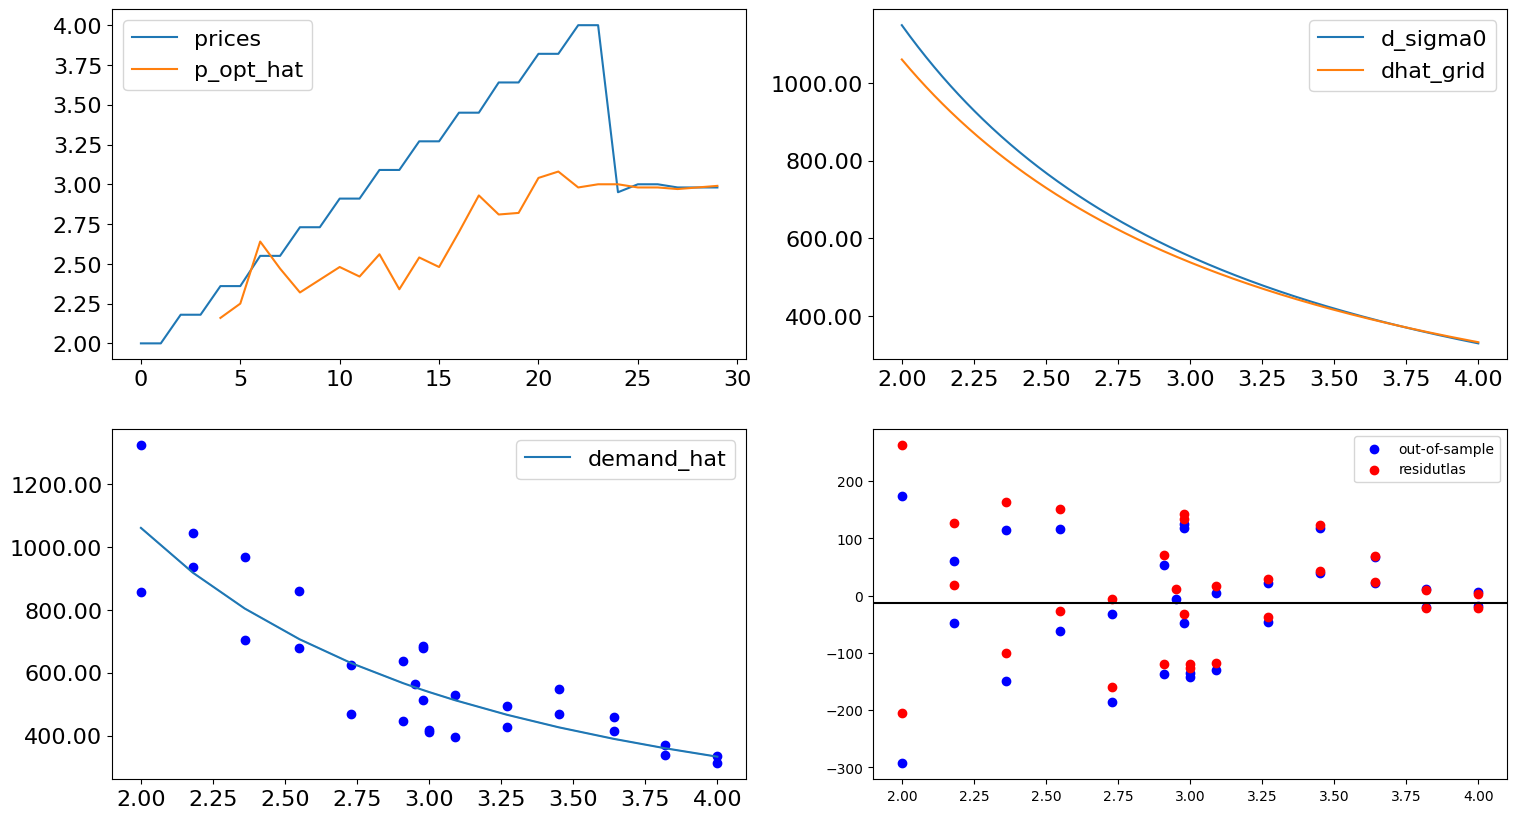

In [31]:

# Evaluate Demand and Price Fit Function
print(f'Experiment k = {k}')
print(f'demand_type =  {demand_type}')
print(f'demand_params = {demand_params}')
print(f'selected_model_type = {df_mab_results["selected_model"].iloc[-1]}')
print(f'N_regions = {N_regions}')
print(f'N_overlap = {N_overlap}')

_p = df_mab_results["p_history"].to_list()
_d = df_mab_results["d_history"].to_list()
_p = [float(p) for p in _p]
_d = [float(d) for d in _d]
print(f'demand_type = {demand_type}')
print(f'demand_params = {demand_params}')
print("sigma_log =", sigma_log)
print(f"price_history = {_p}")
print(f"demand_history = {_d}")
print("d_opt_hat_history = ", df_mab_results["d_opt_hat_history"].to_list())

dhat_model = results_dict_k["dhat_model"]
model_info = results_dict_k["model_info"]

_fig, axs = plt.subplots(nrows=2,ncols=2, figsize=(18,10))

# Sort by p values (ascending)
sorted_pairs = sorted(zip(_p, _d), key=lambda x: x[0])
p_sorted, d_sorted = map(list, zip(*sorted_pairs)) # Unzip back to lists
d_hat_sorted = dhat_model(p_sorted)
d_hat_unsorted = dhat_model(_p)

# demand
print(f'd_hat_history = {d_hat_unsorted}')  # predicted demand by model at price 
d_sigma0_history =df_mab_results["d_sigma_0_history"].to_list()
print(f'd_sigma0_history = {d_sigma0_history}')  # ideal demand

d_sigma0_sorted = get_demand( demand_type, demand_params, p_sorted,  sigma_log=0)

# errors 
#errors = list( (np.asarray(d_hat_sorted)- np.asarray(d_sigma0_sorted)) )
#print(f'errors_out_of_sample = {errors}')

# error vs ideal demand
errors= d_sorted - d_sigma0_sorted
errors = [float(e) for e in errors]
print(f'errors out-of-sample (observed demand - ideal demand) = {errors}')

# error vs fitted curve (residuals)
errors_residual =  d_sorted - d_hat_sorted
errors_residual = [float(e) for e in errors_residual]
print(f'errors residual (observed demand - fitted demand) = {errors_residual}')


# noiseless demand curve
p_grid = np.linspace(min(p_sorted), max(p_sorted), 500)
d_sigma0_grid=get_demand(demand_type, demand_params, p_grid, sigma_log=0)
d_hat_grid = dhat_model(p_grid)

# dataframes for plotting
df = pd.DataFrame({
    "price": p_sorted,
    "observed": d_sorted,
    "d_sigma0": d_sigma0_sorted,
    "demand_hat": d_hat_sorted,
    "error": errors,
})

error_avg = df.error.mean()

df_grid = pd.DataFrame({
    "price": p_grid,
    "d_sigma0": d_sigma0_grid,
    "dhat_grid": d_hat_grid
})

p_history = df_mab_results["p_history"]
p_opt_hat_history = df_mab_results["p_opt_hat_history"]
d_history = df_mab_results["d_history"]
d_sigma0_history = df_mab_results["d_sigma_0_history"]

df_unsorted=pd.DataFrame({ "i": range(len(p_history)) , "prices":p_history, "p_opt_hat": p_opt_hat_history, "demand": d_history, "d_sigma0_history": d_sigma0_history})

# price history vs. i
bp.lineplot(
    df_unsorted, x = "i", y = ["prices","p_opt_hat"],
    ax = axs[0][0])

# dhat and d observed
bp.lineplot(
        df,
        x="price",
        y=["demand_hat"],
        linestyle = "-",
    ax = axs[1][0],
    )

axs[1][0].scatter(_p,_d,marker="o", color = "blue")

# dhat and d_sigma0 vs. price grid
bp.lineplot(
        df_grid,
        x="price",
        y=["d_sigma0", "dhat_grid" ],
        linestyle = "-",
    ax = axs[0][1],
    )

# errors vs. price
# red in sample error, blue out of sample error
axs[1][1].scatter(p_sorted,errors,marker="o", color = "blue", label="out-of-sample")
axs[1][1].scatter(p_sorted,errors_residual,marker="o", color = "red",label="residutlas")
axs[1][1].axhline(y=error_avg, color='k', linestyle='-')
axs[1][1].legend()

# Calculate Optimums via price grid
d_grid_hat = dhat_model(p_grid) 
profit_grid_hat = (p_grid- c) * d_grid_hat - F
i_opt = np.argmax(profit_grid_hat)
p_opt_hat = p_grid[i_opt]
d_opt_hat = d_grid_hat[i_opt]
profit_opt_hat = profit_grid_hat[i_opt]

# print opt results
print(f'p_opt_hat = {df_mab_results["p_opt_hat_history"].iloc[-1]}')
print(f'd_opt_hat = {df_mab_results["d_opt_hat_history"].iloc[-1]}')
print(f'profit_opt_hat = {df_mab_results["profit_opt_history"].iloc[-1]}')

plt.show()
    

# Improving Fitted Error

### Tilted Curve due to Large Residuals

Tilted Curve due to large residuals

In certain situations, the fitted curve looks tilted vs the ideal demand. This is evident in the following sets of errors (residuals, and out-of-sample)

errors out-of-sample (observed demand - ideal demand) = [-197.29835499703483, -33.5983549970349, 206.7551945062329, -132.04480549376717, -137.2434377181014, -82.44343771810145, 83.498569407697, 116.498569407697, -99.49575320758606, -105.19575320758611, -76.56093087565245, -137.16093087565247, -163.4702931238453, -198.4702931238453, -101.70445530810741, -63.70445530810741, 138.27027274696337, -33.63904905633615, -12.339049056336137, -9.269225773168273, -27.824780036841446, -49.22478003684142, 7.687644319282185, -22.91235568071778, 73.58935160780123, -8.510648392198789, 121.11820687111344, -71.78179312888653, 136.62302230677653, 118.52302230677651]

errors residual (observed demand - fitted demand) = [-35.9545494052328, 127.74545059476714, 325.29956322258806, -13.500436777412006, -50.47920444400006, 4.320795555999894, 145.10031059549794, 178.10031059549794, -56.0325044398885, -61.732504439888544, -47.17673651626586, -107.77673651626588, -145.12351781461842, -180.12351781461842, -92.08223845748091, -54.08223845748091, 145.80413098647523, -26.50729187771043, -5.207291877710418, -2.534546795383335, -23.002539506230733, -44.40253950623071, 10.36689769283771, -20.233102307162255, 70.43953424475222, -11.660465755247799, 113.55960441498604, -79.34039558501394, 125.51243417614637, 107.41243417614635]

The largest residuals are indeed at the lower prices: +325, +178, +146. +125 ... but there are also large negative residuals: -180, -145, -108 ...  It looks like high leverage: the few low-price observations have much larger influence because demand is much larger there.

Try one of these:

Huber regression (my favorite). Replace OLS/Ridge with a robust regression that automatically downweights large residuals. It is almost a drop-in replacement and directly addresses those +325 and -180 residuals.

Winsorize log-residuals. Clip the largest residuals before fitting. Simpler, though more ad hoc.

Iteratively reweighted least squares (IRLS). Fit → compute residuals → downweight large residuals → refit. This is essentially what Huber does.

Given your eventual BigQuery implementation, lean toward IRLS. It is simple:

* Fit once.
* Compute log residuals.
* Compute weights from residual magnitude.
* Refit once.
* Stop.

Only two regression passes, easy to implement in SQL, and it specifically reduces the influence of the high-leverage observations that appear to be tilting your curve.

# Strategy to address Tilted Fitted Demand Curve

Piecewise-local elasticity model rather than one global slope. Conceptually:

* split the price range into low / middle / high regions,
* fit a simple local model in each region,
* allow the regions to overlap so the transition is smooth,
* combine the regional predictions with weights that vary continuously with price.

Overlapping regions with weighted blending over hard boundaries. Hard piecewise fits can create discontinuities in d(p) or in elasticity, which could make the profit optimizer unstable.